# Chapter 12.2 — Types of Sentiment Analysis and the Business Insight

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 12.1 put one label on every review. This part asks what that label hides (how strong the opinion is, which emotion it carries, which part of the shop it is about) and turns the answers into the one thing the owner wanted to know: what to fix first.

**In this chapter:** Recap of 12.1 · Four types · Fine-grained · Emotion detection · Aspect-based · Complaints by aspect · Machine-learning-based · Word embeddings · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Tell the four types apart**: standard, fine-grained, emotion detection and aspect-based, by the question each answers and the output it gives.
> - **Read a review by aspect**: cut it into clauses, name the aspect of each, and label each one.
> - **Turn labels into a decision** by counting the complaints per aspect.
> - **Say how a classifier learns sentiment** from rated reviews, in Chapter 10's terms, and what its limit is.



**Contents**

- **12.2.1 · Where Part 12.1 left the reviews** — recap, and what one label hides
- **12.2.2 · Four types of sentiment analysis** — the map
- **12.2.3 · Fine-grained sentiment analysis** — five levels instead of three
- **12.2.4 · Emotion detection** — which feeling, not only which sign
- **12.2.5 · Aspect-based sentiment analysis** — one review, several opinions
- **12.2.6 · Interpretation** — from labels to a decision
- **12.2.7 · Machine-learning-based sentiment analysis** — an overview
- **12.2.8 · Word embeddings** — a word as a list of numbers
- **12.2.9 · Glossary** — the new terms of this part
- **12.2.10 · Where the course leaves us** — Chapters 9 to 12
- **12.2.11 · Homework** — the sixteen cafe reviews again



> **How to use this notebook.** Each type of analysis is explained first, with a review worked by hand, and then run in code one step per cell: the text above a code cell says what it does and why, and the Interpretation under it reads the result. Everything reuses the thirty reviews, the lexicon and the three-label function of Part 12.1.



## 12.2.1 · Where Part 12.1 left the reviews

*recap, and what one label hides*

> **Recap from Part 12.1.** Each review was lowercased, cut into tokens and stripped of stop words. Every token was looked up in the VADER lexicon of about 7,500 scored words, the rules for *not*, *really* and *but* adjusted the scores, and the sum was turned into a compound score between −1 and +1. Cut at ±0.05, the compound score gave **15 positive, 13 negative and 2 neutral** reviews, agreeing with the star ratings on 28 of 30. The two neutrals, *cold* and *the app crashes*, are complaints in words the lexicon does not have.



#### What one label hides

Review 30: *The noodles were delicious, but the delivery was a disaster, two hours late.* Compound −0.65, label **negative**.

- **The label is right**, and it throws away half the review: the food was praised.
- **A shop that reads only the label** learns that a customer was unhappy.
- **A shop that reads by aspect** learns to keep the recipe and fix the delivery.

This part recovers what the single label threw away, one type of analysis per section, and ends with what the owner should do first.



#### The thirty reviews again

Part 12.1 rebuilt in two cells, starting with the thirty reviews. Colab lacks VADER, so this cell installs it once.



In [1]:
try:
    import vaderSentiment
except ImportError:              # Colab does not include VADER; install it once
    %pip install -q vaderSentiment

import pandas as pd
pd.set_option("display.max_colwidth", 80)

reviews = pd.DataFrame([
    ["The noodles were delicious and the broth was rich.", 5],
    ["Great value for the price, a big portion for 60 baht.", 5],
    ["Friendly staff and very quick service.", 5],
    ["The delivery was fast and the food arrived hot, perfect.", 5],
    ["The app is easy to use and ordering took one minute.", 4],
    ["Tasty food, fair price, will order again.", 5],
    ["The driver was friendly and arrived early.", 4],
    ["Excellent soup, the best in town.", 5],
    ["Good portions and a fair price.", 4],
    ["The staff were helpful when I changed my order.", 4],
    ["Fast delivery and the packaging kept everything warm.", 5],
    ["Love the new app, the order button is easy to find.", 5],
    ["Fresh vegetables and a wonderful spicy broth.", 5],
    ["A fair price for such a generous bowl.", 4],
    ["The service was quick and the food was great.", 5],
    ["The delivery took two hours and the noodles were cold.", 1],
    ["Terrible service, the staff ignored us.", 1],
    ["Overpriced and disappointing for such a small portion.", 2],
    ["The app crashes every time I open it.", 1],
    ["The driver was rude and the order was wrong.", 1],
    ["The broth was bland and the noodles were a disappointment.", 2],
    ["Slow service and a dirty table.", 2],
    ["The price went up again, not worth it anymore.", 2],
    ["Late delivery and a useless phone line, nobody answered.", 1],
    ["The app is a mess, it logged me out twice during payment.", 2],
    ["Awful food, the meat was not fresh.", 1],
    ["The delivery was late again and the driver was rude.", 1],
    ["Poor value, the portion was tiny for the price.", 2],
    ["Bad packaging, the bag was leaking and the order arrived late.", 1],
    ["The noodles were delicious, but the delivery was a disaster, two hours late.", 2],
], columns=["review", "stars"])
reviews.index = range(1, 31)
print("reviews:", reviews.shape)

reviews: (30, 2)


#### The lexicon and the labels of Part 12.1

The analyzer, the tokenizer and the three-label function, then the compound score and the label of every review.



> **Interpretation.** 15 positive, 13 negative, 2 neutral: the end of Part 12.1. The table now carries a compound and a sentiment column, and analyzer, tokenize and sentiment_of are ready for the sections below.



In [2]:
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
tokenize = CountVectorizer().build_analyzer()        # lowercase, drop punctuation, split into words

def sentiment_of(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

reviews["compound"] = [analyzer.polarity_scores(t)["compound"] for t in reviews["review"]]
reviews["sentiment"] = reviews["review"].apply(sentiment_of)
reviews["sentiment"].value_counts()

sentiment
positive    15
negative    13
neutral      2
Name: count, dtype: int64

## 12.2.2 · Four types of sentiment analysis

*the map*

All four types below can be built on the lexicon and rules of Part 12.1. The output changes because the question changes.

| Type | The question it answers | Its output |
|---|---|---|
| **Standard** | Is the opinion positive, negative or neutral? | one of three labels per text (Part 12.1) |
| **Fine-grained** | How strong is the opinion? | one of five levels, from very negative to very positive |
| **Emotion detection** | Which feeling is behind it? | emotions such as happiness, anger, frustration |
| **Aspect-based** | What is each opinion about? | one label per aspect: food, price, service, delivery |

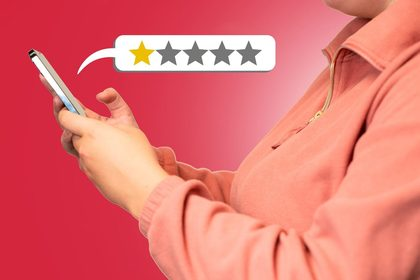

*An online review with its star rating: the kind of text all four types read. — Photo: “Reviews of a Negative Customer Experience” by Zuko.io Images, CC BY*



## 12.2.3 · Fine-grained sentiment analysis

*five levels instead of three*

> **Definition.** **Fine-grained sentiment analysis** cuts the same compound score into five levels instead of three: **very negative, negative, neutral, positive, very positive**. ±0.05 still marks the neutral band, and ±0.5 separates *very* from merely positive or negative, the way a star rating has more than three values.

| Review | Compound | Standard label | Fine-grained level |
|---|---|---|---|
| **1 · *delicious … rich*** | +0.81 | positive | very positive |
| **3 · *friendly staff and very quick service*** | +0.49 | positive | positive |
| **16 · *two hours … cold*** | 0.00 | neutral | neutral |
| **22 · *slow service and a dirty table*** | −0.44 | negative | negative |
| **17 · *terrible service … ignored us*** | −0.66 | negative | very negative |

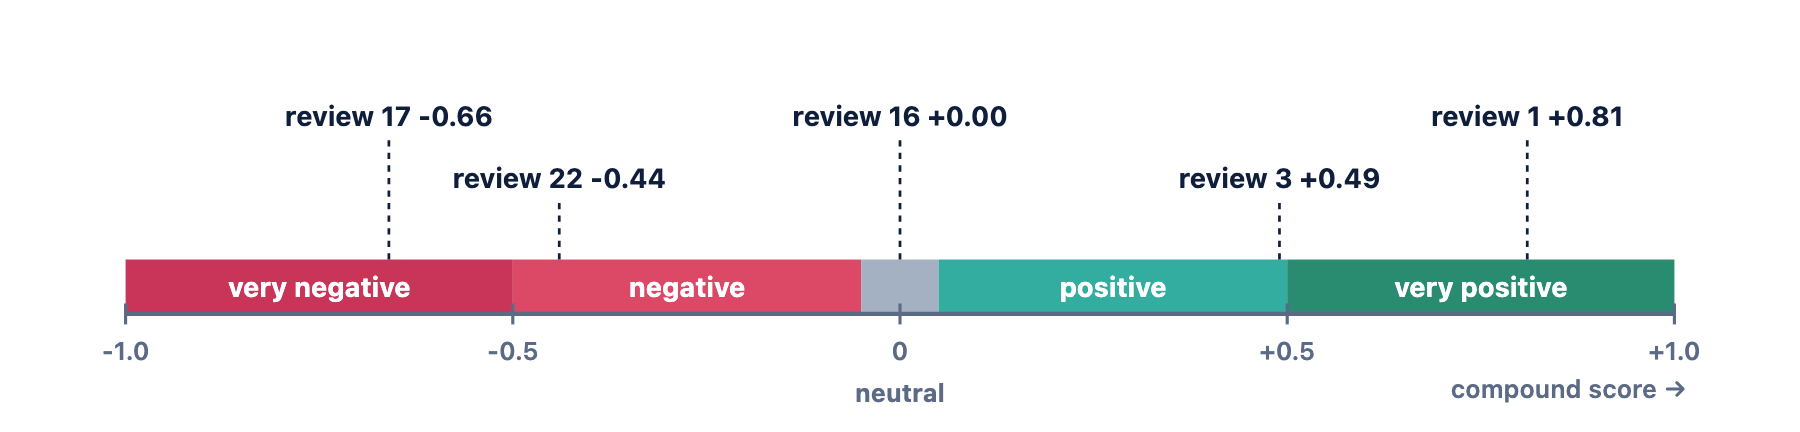

*The five fine-grained levels, cut from the same compound score at −0.5, −0.05, +0.05 and +0.5, with five of the thirty reviews marked.*



#### What moves a review to very

- **Two scored words instead of one**: review 1 has *delicious* (+2.7) and *rich* (+2.6).
- **An intensifier or an exclamation mark**, as in Section 12.1.8.
- **One strongly scored word**: *disaster* is −3.1.
- **Review 3 stays merely positive**: *friendly* is scored, but *quick* is not in the lexicon.



#### Five levels from the same score

`pd.cut` cuts a column of numbers into bands: `bins` are the edges and `labels` the names of the bands between them. The count is shown in order from very negative to very positive, then the five reviews of the table.

$$\text{very negative} \le -0.5 < \text{negative} \le -0.05 < \text{neutral} < 0.05 \le \text{positive} < 0.5 \le \text{very positive}$$



> **Interpretation.** Reading the five levels:
>
> - **9 very positive, 6 positive, 2 neutral, 7 negative, 6 very negative.** The standard labels said 15 and 13; the finer cut says most of the praise is strong and the complaints are split between mild and strong.
> - **The five reviews** get the levels of the hand table.



In [3]:
order = ["very negative", "negative", "neutral", "positive", "very positive"]
reviews["level"] = pd.cut(reviews["compound"], bins=[-1, -0.5, -0.05, 0.05, 0.5, 1], labels=order)

print(reviews["level"].value_counts().reindex(order), "\n")
reviews.loc[[1, 3, 16, 22, 17], ["review", "compound", "sentiment", "level"]]

level
very negative    6
negative         7
neutral          2
positive         6
very positive    9
Name: count, dtype: int64 



,review,compound,sentiment,level
1,The noodles were delicious and the broth was rich.,0.8074,positive,very positive
3,Friendly staff and very quick service.,0.4939,positive,positive
16,The delivery took two hours and the noodles were cold.,0.0000,neutral,neutral
22,Slow service and a dirty table.,-0.4404,negative,negative
17,"Terrible service, the staff ignored us.",-0.6597,negative,very negative


#### Try it: move the edges

> **Try it.** Change the inner edges from −0.05 and 0.05 to −0.2 and 0.2, and run the cell again.
>
> *Answer.* Neutral grows from 2 to 4: reviews 23 and 28, mild complaints at about −0.17, move into the middle band. Where the edges sit is a decision, not a fact.



## 12.2.4 · Emotion detection

*which feeling, not only which sign*

> **Definition.** **Emotion detection** asks what the customer felt (happiness, anger, frustration) rather than whether the opinion was positive or negative. The simplest tool is again a lexicon, one that maps words to an emotion instead of to a score.

A small emotion lexicon, written by hand for this shop:

| Emotion | Words |
|---|---|
| **happiness** | love, delicious, wonderful, excellent, great, perfect |
| **anger** | rude, terrible, awful, ignored, disaster |
| **frustration** | crashes, late, again, wrong, twice, mess |



#### Worked example: four reviews

| Review | Words found | Emotion |
|---|---|---|
| **12 · *Love the new app …*** | love | happiness |
| **17 · *Terrible service, the staff ignored us.*** | terrible, ignored | anger |
| **19 · *The app crashes every time I open it.*** | crashes | frustration |
| **27 · *The delivery was late again and the driver was rude.*** | rude · late, again | anger and frustration |

> **Why a business wants the emotion.** Reviews 17 and 19 are both negative. An angry customer (17) wants an apology and someone to talk to; a frustrated one (19) wants the bug fixed. The standard label says negative for both; the emotion says what to do.



#### The emotion of a review

`emotion_words` is the table above as a dictionary. `emotion_of` cuts a review into tokens and lists every emotion that has at least one of its words among them.



> **Interpretation.** The four rows of the worked example. Review 27 carries two emotions at once, and nothing requires a review to carry only one.



In [4]:
emotion_words = {"happiness":   ["love", "delicious", "wonderful", "excellent", "great", "perfect"],
                 "anger":       ["rude", "terrible", "awful", "ignored", "disaster"],
                 "frustration": ["crashes", "late", "again", "wrong", "twice", "mess"]}

def emotion_of(text):
    tokens = tokenize(text)
    found = [emotion for emotion, words in emotion_words.items() if any(w in tokens for w in words)]
    return ", ".join(found) if found else "none detected"

for n in [12, 17, 19, 27]:
    print(f"review {n}: {emotion_of(reviews.loc[n, 'review'])}")

review 12: happiness
review 17: anger
review 19: frustration
review 27: anger, frustration


#### A caution on emotion lexicons

- **Real emotion lexicons** hold thousands of words per emotion. This one holds six per emotion and works only because its words were chosen from these reviews.
- **A word can change its meaning with context**: *she feels sick* is negative, *that trick was sick!* is praise. A lexicon sees the word and not the context, so it works best on one kind of text, such as reviews, where the vocabulary is predictable.



## 12.2.5 · Aspect-based sentiment analysis

*one review, several opinions*

Fine-grained levels and emotions still give one answer per review. Review 30 needs two.

> **Definition.** **Aspect-based sentiment analysis** cuts a review into clauses, names the **aspect** each clause is about, and labels each clause on its own. An aspect is one part of the thing reviewed: for this shop, food, price, service, delivery and the app.

| Aspect | Key words |
|---|---|
| **delivery** | delivery, driver, arrived, packaging, bag, phone, late |
| **app** | app, button, ordering, payment, logged |
| **service** | staff, service, table |
| **price** | price, value, baht, overpriced, worth |
| **food** | noodles, broth, soup, food, meat, vegetables, portion, portions, bowl |

A clause is cut at every comma and at *but*, and named by the first aspect in the list whose key word it contains; a clause with none is *general*.



#### Worked example: review 30

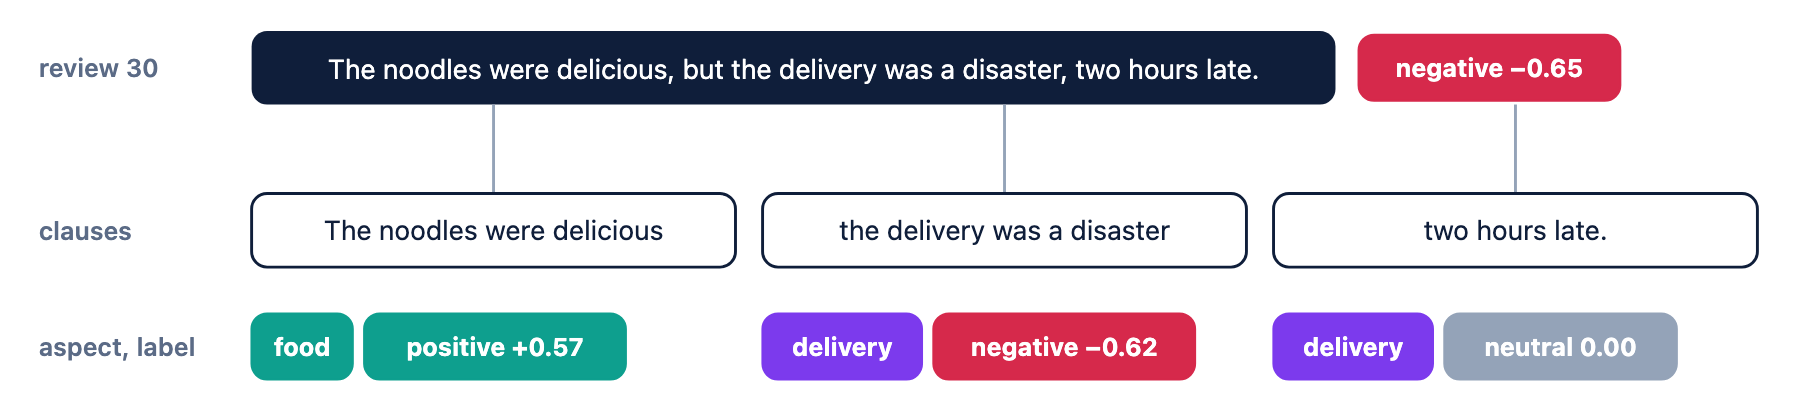

*Review 30 cut at its commas and at “but”. Each clause gets its own aspect and its own label; the whole-review label hides the praise for the food.*

- ***The noodles were delicious*** → food, positive (+0.57).
- ***the delivery was a disaster*** → delivery, negative (−0.62).
- ***two hours late*** → delivery, but neutral: *late* names the aspect, yet it has no score.

The same split works on Section 12.1.8's *The hotel was good, but the food was really bad*: *the hotel was good* is positive (+0.44), *the food was really bad* negative (−0.58). A hotel would keep the location and fix the kitchen.



#### The steps

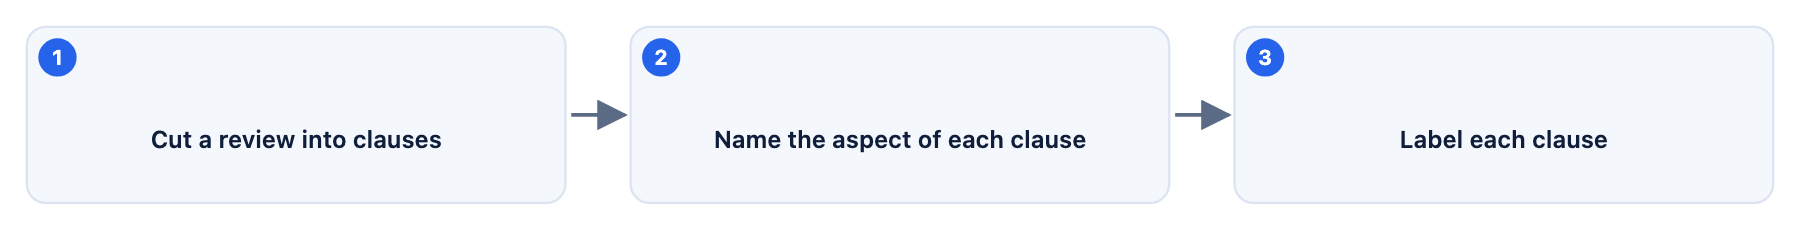

*The code of this section, on review 30.*



#### Clauses and aspects

`clauses_of` cuts a text with `re.split(r",|\bbut\b", text)`: the pattern means “a comma, or the whole word but”. `aspect_of` returns the first aspect whose key words appear among the clause's tokens. Both are then used on review 30.



> **Interpretation.** The three rows of the worked example: food positive, delivery negative, delivery neutral. The one review now carries two opinions, and the shop knows what to keep and what to fix.



In [5]:
aspect_words = {"delivery": ["delivery", "driver", "arrived", "packaging", "bag", "phone", "late"],
                "app":      ["app", "button", "ordering", "payment", "logged"],
                "service":  ["staff", "service", "table"],
                "price":    ["price", "value", "baht", "overpriced", "worth"],
                "food":     ["noodles", "broth", "soup", "food", "meat", "vegetables", "portion", "portions", "bowl"]}

def clauses_of(text):
    return [part.strip() for part in re.split(r",|\bbut\b", text) if part.strip()]

def aspect_of(clause, words=aspect_words):
    tokens = tokenize(clause)
    for aspect, keys in words.items():
        if any(k in tokens for k in keys):
            return aspect
    return "general"

for clause in clauses_of(reviews.loc[30, "review"]):
    print(f"{clause!r:32} -> {aspect_of(clause):9} {sentiment_of(clause)}")

'The noodles were delicious'     -> food      positive
'the delivery was a disaster'    -> delivery  negative
'two hours late.'                -> delivery  neutral


#### The key words are written for the business

The list of aspects is written by hand for this shop. A hotel would list *room*, *pool* and *breakfast*; a software company *interface*, *speed* and *support*. Section 12.2.6 uses the list on every review.



## 12.2.6 · Interpretation

*from labels to a decision*

Step 6 of the workflow of Section 12.1.4 is **interpretation**: turning the labels into something the business can act on. With a label per aspect, the step is a count. Every review is cut into clauses, every clause gets an aspect and a label, and the clauses are counted per aspect.

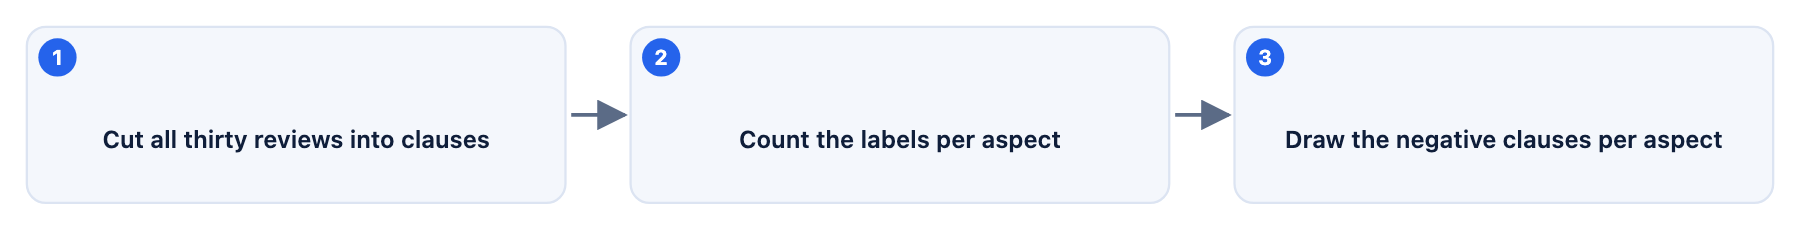

*The code of this section.*



#### Every clause of every review

One row per clause: the review it came from, the clause, its aspect and its label. The first eight rows are shown.



> **Interpretation.** 45 clauses from 30 reviews: most reviews are one clause, and a few, such as review 2 and review 30, are two or three.



In [6]:
rows = [(n, clause, aspect_of(clause), sentiment_of(clause))
        for n, text in reviews["review"].items() for clause in clauses_of(text)]
mentions = pd.DataFrame(rows, columns=["review", "clause", "aspect", "sentiment"])
print("clauses:", len(mentions))
mentions.head(8)

clauses: 45


,review,clause,aspect,sentiment
0,1,The noodles were delicious and the broth was rich.,food,positive
1,2,Great value for the price,price,positive
2,2,a big portion for 60 baht.,price,neutral
3,3,Friendly staff and very quick service.,service,positive
4,4,The delivery was fast and the food arrived hot,delivery,neutral
5,4,perfect.,general,positive
6,5,The app is easy to use and ordering took one minute.,app,positive
7,6,Tasty food,food,neutral


#### The labels per aspect

`pd.crosstab` counts the clauses of each aspect by label, so praise and complaints can be read side by side.



> **Interpretation.** Reading the table:
>
> - **Delivery**: 5 negative clauses and 2 positive. The most complaints and among the fewest compliments.
> - **Food**: 4 positive and 3 negative. **Price**: 4 positive and 3 negative. Both are mostly praised.
> - **Service** is split 3 and 3; **the app** has 1 negative and 3 positive.



In [7]:
pd.crosstab(mentions["aspect"], mentions["sentiment"])

sentiment,negative,neutral,positive
aspect,,,
app,1,2,3
delivery,5,4,2
food,3,1,4
general,0,2,2
price,3,3,4
service,3,0,3


#### The complaints, drawn

The negative clauses alone, counted per aspect and drawn from most to fewest.



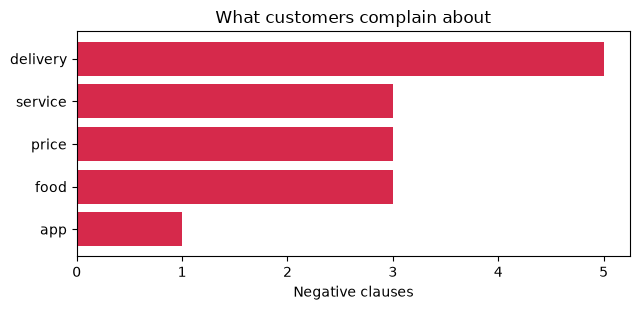

In [8]:
complaints = mentions[mentions["sentiment"] == "negative"]["aspect"].value_counts()

plt.figure(figsize=(6.5, 3.2))
plt.barh(complaints.index[::-1], complaints.values[::-1], color="#D6294B")
plt.xlabel("Negative clauses")
plt.title("What customers complain about")
plt.tight_layout()
plt.show()

#### Reading the chart

> **Interpretation.** The count is the business insight:
>
> - **Delivery has 5 negative clauses**; service, price and food have 3 each; the app has 1.
> - **Delivery was also among the most frequent words** in Section 12.1.6: customers write about it most and like it least.
> - **The decision**: fix the delivery first (more drivers, better packaging, a phone line that answers) before changing the recipe or the price.



#### Reading the count honestly

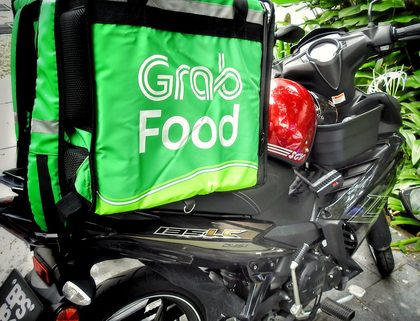

*Food delivery by motorcycle: the aspect the reviews complain about most. — Photo: “Grab Clobbered Uber in SE Asia” by Dennis S. Hurd, CC0*

- **Thirty reviews are a small sample.** The direction of the insight is safe; the exact numbers are not. Real review streams arrive by the thousand, and there the counts settle.
- **Some complaints were missed**: *cold* and *late* have no score, so clauses such as *two hours late* count as neutral. The true delivery count is higher, not lower.



## 12.2.7 · Machine-learning-based sentiment analysis

*an overview*

Every method so far used a lexicon written by people, and that lexicon has no entry for *cold*, *late* or *crashes*. The other route to a label is supervised learning.

> **Recap from Chapters 9 and 10.** A supervised model learns from **labeled data**: examples whose answer is already known (Section 9.3). In Chapter 10.1 a decision tree was built with one call, `fit`, and used with another, `predict`. How good a model is, is judged on examples it did not learn from (Section 9.3.2).

For text, the star ratings supply the labels and the bag of words of Section 12.1.6 supplies the features:

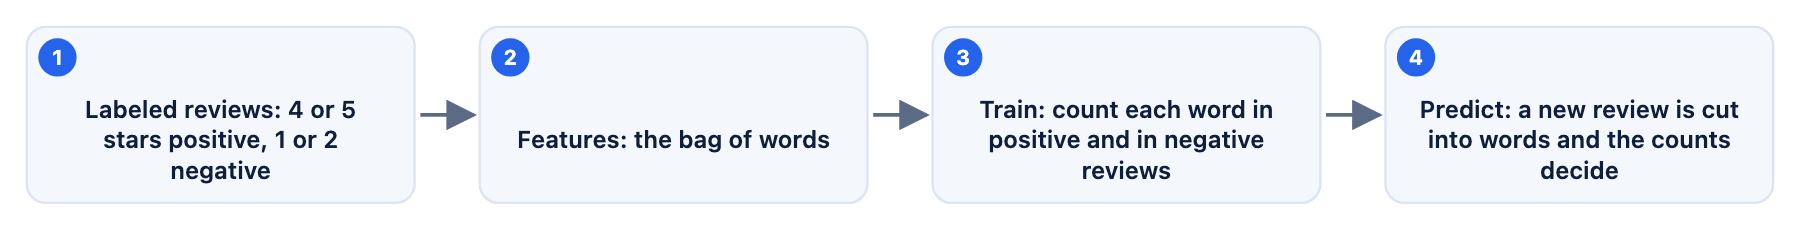

*Sentiment analysis as supervised learning.*



#### The labels from the stars

A review rated 4 or 5 stars is labeled positive and one rated 1 or 2 negative. These labels come from the customers themselves, not from a lexicon.



> **Interpretation.** 15 and 15: reviews 1 to 15 positive, 16 to 30 negative.



In [9]:
reviews["label"] = ["positive" if s >= 4 else "negative" for s in reviews["stars"]]
reviews["label"].value_counts()

label
positive    15
negative    15
Name: count, dtype: int64

#### Train, then predict three new reviews

`make_pipeline` joins two steps into one model: the bag of words, then a **Naive Bayes** classifier, which counts how often each word appears in positive and in negative reviews. `fit` trains it on the thirty reviews; `predict` labels three reviews it has never seen, printed beside the lexicon's label.



> **Interpretation.** Reading the three predictions:
>
> - **The same two calls as the tree of Chapter 10.1**, with text in place of a table of features.
> - ***The app crashes and the order was late*** is **negative** for the model and **neutral** for the lexicon. The model learned from the rated reviews that *crashes* and *late* go with 1 and 2 stars; the lexicon was never told.
> - **The other two** get the same label from both.



In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(CountVectorizer(stop_words="english"), MultinomialNB())
model.fit(reviews["review"], reviews["label"])

new_reviews = ["The soup was tasty and the driver was friendly.",
               "The app crashes and the order was late.",
               "Cold noodles and a rude driver."]
pd.DataFrame({"review": new_reviews,
              "model": model.predict(new_reviews),
              "lexicon": [sentiment_of(t) for t in new_reviews]})

,review,model,lexicon
0,The soup was tasty and the driver was friendly.,positive,positive
1,The app crashes and the order was late.,negative,neutral
2,Cold noodles and a rude driver.,negative,negative


#### The words the model learned

Inside the classifier sits a count: `feature_count_`, how many times each word appeared in negative and in positive reviews. The words used three times or more are listed, with how far each leans toward negative.



> **Interpretation.** A lexicon that nobody wrote:
>
> - ***Late*: 4 negative, 0 positive**, the model's strongest negative word, and one the human lexicon does not have. ***Fair*: 0 and 3** is its clearest positive word.
> - ***Delivery* leans negative (4 to 2) and *price* positive (2 to 4)**, though neither word is an opinion. The model learned this shop's pattern, not the meaning of the words; another shop would teach it differently.



In [11]:
words = model[0].get_feature_names_out()
learned = pd.DataFrame(model[1].feature_count_.T, index=words, columns=model[1].classes_).astype(int)
learned["leans"] = learned["negative"] - learned["positive"]       # above 0: seen more in negative reviews
learned[learned[["negative", "positive"]].sum(axis=1) >= 3].sort_values("leans", ascending=False)

,negative,positive,leans
late,4,0,4
delivery,4,2,2
noodles,3,1,2
driver,2,1,1
portion,2,1,1
app,2,2,0
service,2,2,0
arrived,1,2,-1
broth,1,2,-1
order,2,3,-1


#### The limit of a learned classifier

- **It knows only the words its training reviews contain.** A complaint in words none of the thirty reviews used would leave it guessing.
- **How good it is** would be measured as in Chapter 10.2: predictions on reviews held back from training, compared with their stars. Thirty reviews are too few for that score to mean much, so none is reported here.



## 12.2.8 · Word embeddings

*a word as a list of numbers*

In the bag of words every word is a column of its own, so *delicious* and *tasty* are as unrelated as *delicious* and *late*.

> **Definition.** A **word embedding** represents each word by a short list of numbers, a **vector**, chosen so that words used in similar sentences get similar numbers.

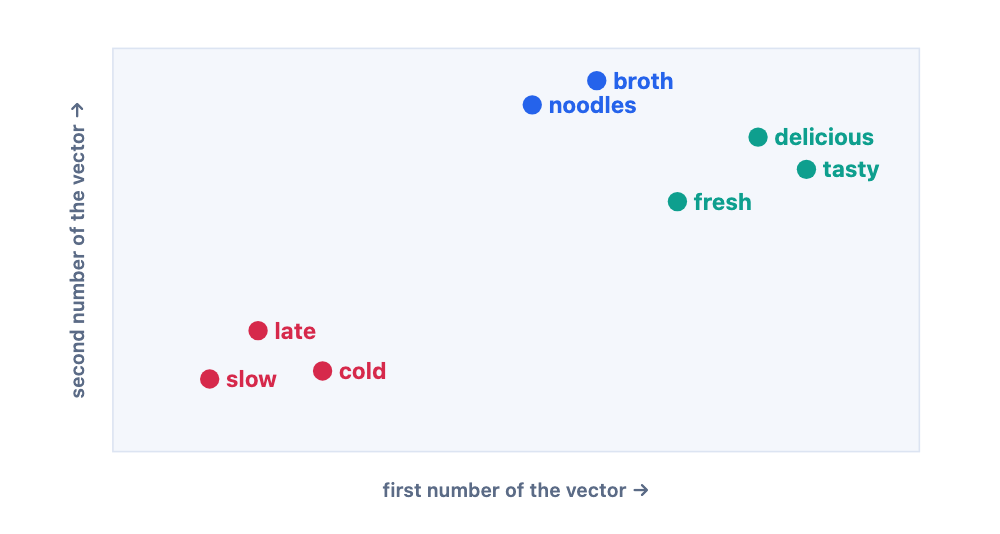

*An illustration, not real values: each word drawn at two of its numbers. Words used in similar sentences sit close together.*



#### What the numbers give

- **Reading the figure**: each word is drawn at the first number of the vector (across) and the second number of the vector (up). *Delicious*, *tasty* and *fresh* sit together; so do *late*, *cold* and *slow*.
- **Similar words, similar vectors**: a model that has learned *delicious* already knows something about *tasty*, so a review that says *tasty* is understood even if no training review used it.
- **The numbers are found by reading very large amounts of text.** How that is done is beyond this course.
- **Embeddings are the representation under translation, chatbots and modern sentiment models**: the NLP products of Section 12.1.1.



## 12.2.9 · Glossary

*the new terms of this part*

The terms of Part 12.1 (token, stop words, bag of words, lexicon, compound score) are in its own glossary.

| Term | Meaning |
|---|---|
| **Fine-grained sentiment analysis** | Five levels, very negative to very positive, cut from the compound score. |
| **Emotion detection** | Naming the feeling in a text, such as happiness, anger or frustration. |
| **Aspect-based sentiment analysis** | One label per aspect of the thing reviewed. |
| **Aspect** | One part of the thing reviewed: food, price, service, delivery. |
| **Clause** | A part of a sentence, here cut at commas and at but. |
| **Interpretation** | Step 6: turning the labels into a decision. |
| **Machine-learning-based** | A classifier that learns sentiment from labeled texts. |
| **Word embedding** | A word represented as a vector, with similar words given similar vectors. |



## 12.2.10 · Where the course leaves us

*Chapters 9 to 12*

- **Four types, one lexicon**: standard, fine-grained, emotion and aspect-based analysis ask four questions of the same scored words.
- **Aspects turn labels into a decision**: delivery 5 complaints, everything else 3 or fewer. Fix the delivery first.
- **Or a classifier learns the words**: with labels, sentiment is Chapter 10's problem again, and it learned *late*, which no lexicon had.

> **The shape of the course.** A tree, a line, a cluster, an association rule and now a sentiment label all came from the same shape of work: data in a table, a model fitted to it, a result read back as a decision. Text was the last kind of data that had to be turned into a table first.



## 12.2.11 · Homework

*the sixteen cafe reviews again*

The exercises apply this part's four ideas to the cafe reviews of Part 12.1's homework, in the order they were taught. Each exercise has a code cell for your work and a text cell for your answer.

**Student information**: double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework data: sixteen cafe reviews

*run this cell, but do not modify it*

Run this cell once and do not edit it. It defines `cafe`, the sixteen reviews of Part 12.1's homework, so the homework works even if the cells above were not run.



In [12]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
import re
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

cafe = pd.DataFrame([
    ["The coffee was excellent and the croissant was fresh.", 5],
    ["Friendly barista and a cozy place to study.", 5],
    ["Great latte for a fair price.", 4],
    ["The wifi is fast and the seats are comfortable.", 4],
    ["Lovely cake, I will come back tomorrow.", 5],
    ["The staff remembered my order, very kind.", 5],
    ["Good coffee, but the seats are hard.", 4],
    ["A quiet corner and the best espresso in the city.", 5],
    ["The coffee was lukewarm and the cup was chipped.", 1],
    ["Rude staff and a dirty table.", 1],
    ["Too expensive and disappointing for such a small cup.", 2],
    ["The wifi keeps dropping, very frustrating.", 2],
    ["The cake was stale and the coffee was not good.", 1],
    ["We waited twenty minutes, terrible service.", 2],
    ["The price is fair, but the barista was unfriendly.", 2],
    ["No seats at all and the music is too loud.", 1],
], columns=["review", "stars"])
cafe.index = range(1, 17)
print("cafe reviews:", len(cafe))

cafe reviews: 16


#### The homework tools

*run this cell, but do not modify it*

Run this cell once as well and do not edit it: the functions of this part, the cafe's own `cafe_aspect_words`, and the compound score and label of every cafe review.



In [13]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
analyzer = SentimentIntensityAnalyzer()
tokenize = CountVectorizer().build_analyzer()

def sentiment_of(text):
    compound = analyzer.polarity_scores(text)["compound"]
    return "positive" if compound >= 0.05 else "negative" if compound <= -0.05 else "neutral"

def clauses_of(text):
    return [part.strip() for part in re.split(r",|\bbut\b", text) if part.strip()]

def aspect_of(clause, words):
    tokens = tokenize(clause)
    for aspect, keys in words.items():
        if any(k in tokens for k in keys):
            return aspect
    return "general"

cafe_aspect_words = {"price":          ["price", "expensive"],
                     "staff":          ["staff", "barista", "service", "waited"],
                     "place":          ["wifi", "seats", "corner", "place", "table", "music"],
                     "food and drink": ["coffee", "latte", "espresso", "cup", "cake", "croissant"]}
cafe["compound"] = [analyzer.polarity_scores(t)["compound"] for t in cafe["review"]]
cafe["sentiment"] = cafe["review"].apply(sentiment_of)
cafe["sentiment"].value_counts()

sentiment
positive    8
negative    7
neutral     1
Name: count, dtype: int64

#### Exercise 1 — Five levels

Cut the cafe's compound scores into the five fine-grained levels of Section 12.2.3 and count them. How many reviews are very positive, and how does the fine-grained count add to what the three labels said?

*Hint:* `pd.cut` with the same bins and labels.



In [14]:
# YOUR CODE HERE (Exercise 1)

#### Your answer: Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — One review by aspect

Cut review 15 into clauses and give each clause its aspect (with `cafe_aspect_words`) and its label. What does the whole-review label hide?

*Hint:* Section 12.2.5, `aspect_of(clause, cafe_aspect_words)`.



In [15]:
# YOUR CODE HERE (Exercise 2)

#### Your answer: Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — Complaints by aspect

Cut every review into clauses, count the labels per aspect, and draw the negative clauses per aspect. Which aspect should the cafe improve first? Give the count that decides it, and one limit of that count.

*Hint:* Section 12.2.6, `pd.crosstab`.



In [16]:
# YOUR CODE HERE (Exercise 3)

#### Your answer: Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — A learned classifier

Label the cafe reviews from their stars (4 or 5 positive, 1 or 2 negative), train the pipeline of Section 12.2.7, and predict *The latte was lukewarm and the cake was stale.* Compare the prediction with the lexicon's label and explain the difference.

*Hint:* `make_pipeline`, `fit`, `predict`.



In [17]:
# YOUR CODE HERE (Exercise 4)

#### Your answer: Exercise 4

*Double-click this cell and type your answer here.*



#### Bonus: an emotion lexicon for the cafe

Write a small emotion dictionary for the cafe (happiness, anger, frustration, three to six words each, chosen from the reviews) and use the emotion function of Section 12.2.4 on reviews 9, 10, 12 and 14. Which negative reviews are anger and which frustration, and what would the cafe do differently for each?



In [18]:
# YOUR CODE HERE (Bonus)

#### Your answer: the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 4 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime > Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

